# Stat 248 Final Project Notebook

## Time-Series-Driven Predictive Maintenance

This notebook is the main reproducible analysis artifact for the final project. It includes the full workflow from synthetic data generation through preprocessing, time-series feature construction, predictive modeling, diagnostics, visualization, and maintenance-policy evaluation.

## Project question

The central question is whether time-series failure-risk modeling improves maintenance decisions compared with simpler rules such as reactive replacement or fixed-age maintenance.

The project is organized around three steps:

1. simulate a fleet of degrading machines with multivariate sensor streams
2. build short-horizon failure-risk models using time-series features
3. compare maintenance policies that act on those risk estimates

## Reproducibility note

This repository does not rely on an external restricted dataset. Instead, it uses a fully reproducible synthetic benchmark generated inside the codebase. That makes it possible to reproduce all tables and figures directly from this notebook.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.pdm_project.features import build_supervised_frame
from src.pdm_project.modeling import (
    ADVANCED_FEATURES,
    BASELINE_FEATURES,
    RICH_TS_FEATURES,
    calibration_table,
    evaluate_risk_model,
    feature_importance_table,
    fit_risk_model,
    fit_tree_risk_model,
    residual_autocorrelation,
    stationarity_diagnostics,
)
from src.pdm_project.policy import (
    evaluate_policy,
    q_policy_from_table,
    train_dqn_policy,
    train_q_learning_policy,
    tune_threshold_policy,
)
from src.pdm_project.simulator import simulate_fleet

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 120)

## Simulate the raw data

The simulator creates machines with latent health, a stressed operating regime, and three observed sensors: vibration, temperature, and pressure. A machine fails when latent health becomes too low or when a high-hazard event occurs near end of life.

In [2]:
train_raw = simulate_fleet(n_machines=90, seed=2480)
valid_raw = simulate_fleet(n_machines=35, seed=2481)
test_raw = simulate_fleet(n_machines=35, seed=2482)

print(train_raw.shape, valid_raw.shape, test_raw.shape)
train_raw.head()

(4726, 11) (1723, 11) (1941, 11)


,machine_id,t,age,regime,health,vibration,temperature,pressure,failed,failure_time,time_to_failure
0,0,0,1,0,0.992783,0.478805,60.501986,104.297766,0,64,64
1,0,1,2,0,0.987576,0.415949,61.058571,105.554425,0,64,63
2,0,2,3,0,0.982856,0.407480,60.387768,106.195643,0,64,62
3,0,3,4,0,0.975977,0.417245,60.866420,104.951725,0,64,61
4,0,4,5,0,0.965933,0.422346,61.424122,105.620264,0,64,60


## Dataset summary table

Before fitting models, it is useful to summarize the generated dataset across train, validation, and test splits. This provides a compact description of sample size, average failure timing, and sensor ranges.

In [3]:
def dataset_summary(split_name, raw_df):
    grouped = raw_df.groupby("machine_id", sort=True)
    return {
        "split": split_name,
        "n_rows": int(len(raw_df)),
        "n_machines": int(raw_df["machine_id"].nunique()),
        "mean_failure_time": float(grouped["failure_time"].first().mean()),
        "mean_path_length": float(grouped.size().mean()),
        "vibration_min": float(raw_df["vibration"].min()),
        "vibration_max": float(raw_df["vibration"].max()),
        "temperature_min": float(raw_df["temperature"].min()),
        "temperature_max": float(raw_df["temperature"].max()),
        "pressure_min": float(raw_df["pressure"].min()),
        "pressure_max": float(raw_df["pressure"].max()),
    }

dataset_summary_df = pd.DataFrame([
    dataset_summary("train", train_raw),
    dataset_summary("validation", valid_raw),
    dataset_summary("test", test_raw),
])
dataset_summary_df

,split,n_rows,n_machines,mean_failure_time,mean_path_length,vibration_min,vibration_max,temperature_min,temperature_max,pressure_min,pressure_max
0,train,4726,90,51.511111,52.511111,0.268439,1.622538,57.048590,75.607361,96.564894,106.988754
1,validation,1723,35,48.228571,49.228571,0.287116,1.620917,58.507799,75.687182,96.910680,106.958924
2,test,1941,35,54.457143,55.457143,0.323314,1.542831,58.090806,75.346726,96.928394,107.428616


## Visualize example sensor trajectories

This figure helps motivate why the problem is inherently temporal. Sensor values evolve gradually and become more informative when viewed as trajectories rather than isolated snapshots.

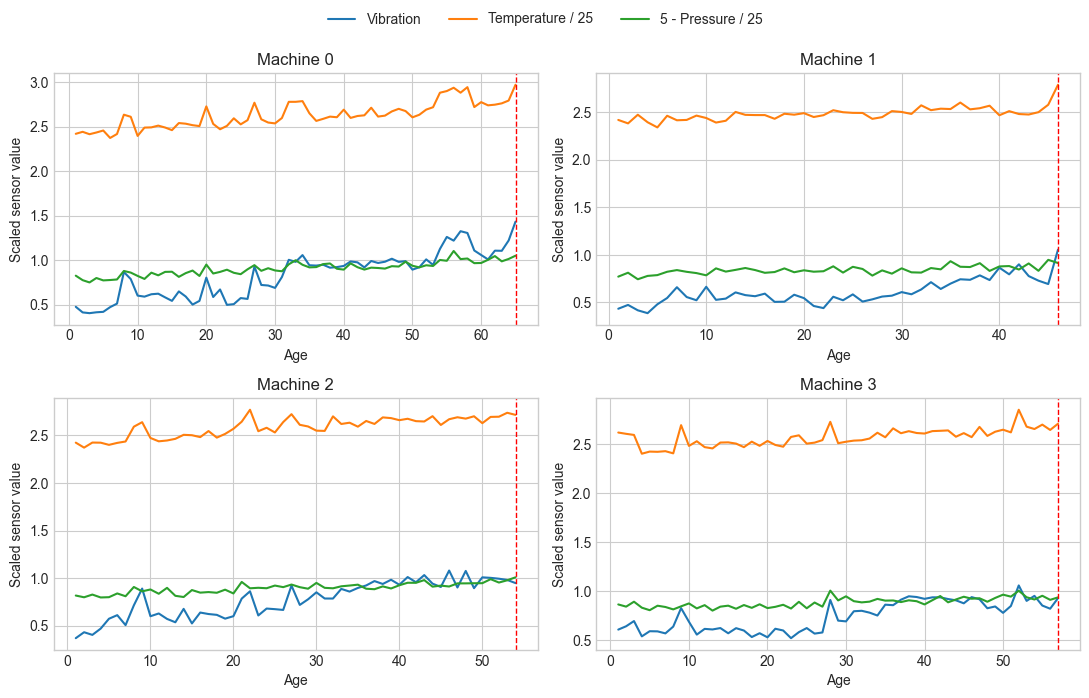

In [4]:
sample_ids = sorted(train_raw["machine_id"].unique())[:4]
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=False)
axes = axes.ravel()

for ax, machine_id in zip(axes, sample_ids):
    sub = train_raw[train_raw["machine_id"] == machine_id]
    ax.plot(sub["age"], sub["vibration"], label="Vibration")
    ax.plot(sub["age"], sub["temperature"] / 25.0, label="Temperature / 25")
    ax.plot(sub["age"], 5.0 - sub["pressure"] / 25.0, label="5 - Pressure / 25")
    ax.axvline(sub["failure_time"].iloc[0] + 1, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"Machine {machine_id}")
    ax.set_xlabel("Age")
    ax.set_ylabel("Scaled sensor value")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Preprocessing and feature construction

The preprocessing step converts raw machine trajectories into a supervised learning frame. The label is whether failure occurs within the next 8 periods. Time-series features include rolling means, rolling standard deviations, rolling slopes, lags, differences, exponentially weighted averages, and Holt summaries.

In [5]:
train_df = build_supervised_frame(train_raw)
valid_df = build_supervised_frame(valid_raw)
test_df = build_supervised_frame(test_raw)

print(train_df.shape, valid_df.shape, test_df.shape)
train_df[[
    "machine_id", "age", "vibration", "vibration_mean_8", "vibration_slope_8",
    "holt_level", "holt_trend", "fail_within_horizon"
]].head(10)

(4726, 68) (1723, 68) (1941, 68)


,machine_id,age,vibration,vibration_mean_8,vibration_slope_8,holt_level,holt_trend,fail_within_horizon
0,0,1,0.478805,0.478805,0.000000,0.478805,0.000000,0
1,0,2,0.415949,0.447377,-0.062857,0.456806,-0.002640,0
2,0,3,0.407480,0.434078,-0.035663,0.437826,-0.004601,0
3,0,4,0.417245,0.429870,-0.019315,0.427632,-0.005272,0
4,0,5,0.422346,0.428365,-0.011162,0.422355,-0.005273,0
5,0,6,0.475163,0.436165,0.000307,0.437411,-0.002833,0
6,0,7,0.514496,0.447355,0.008585,0.462549,0.000523,0
7,0,8,0.869177,0.500083,0.040875,0.605209,0.017580,0
8,0,9,0.790053,0.538989,0.062759,0.681331,0.024605,0
9,0,10,0.604493,0.562557,0.055035,0.670431,0.020344,0


## Why these are time-series features

These engineered variables preserve the project's time-series focus because they summarize local dynamics over time rather than treating each row as a static cross-sectional observation.

## Fit predictive models

I compare three predictive models:

- `baseline_glm`: current age and raw sensor values only
- `advanced_glm`: adds rolling summaries and smoothing-based features
- `nonlinear_ts_forest`: uses a richer nonlinear time-series feature set

In [6]:
baseline_model = fit_risk_model(train_df, BASELINE_FEATURES)
advanced_model = fit_risk_model(train_df, ADVANCED_FEATURES)
tree_model = fit_tree_risk_model(train_df, RICH_TS_FEATURES)

risk_metrics = pd.DataFrame([
    evaluate_risk_model(baseline_model, test_df, "baseline_glm"),
    evaluate_risk_model(advanced_model, test_df, "advanced_glm"),
    evaluate_risk_model(tree_model, test_df, "nonlinear_ts_forest"),
]).sort_values(["auc", "brier"], ascending=[False, True])

risk_metrics

,model,auc,brier,log_loss
2,nonlinear_ts_forest,0.882093,0.092239,0.297159
1,advanced_glm,0.879016,0.093529,0.299711
0,baseline_glm,0.873195,0.094896,0.304488


The main predictive result is that richer temporal representation improves predictive performance. The nonlinear forest performs best on the test set, which suggests that the failure process contains nonlinear interactions among time-series features.

## Feature importance

To better interpret the strongest nonlinear model, I also examine its top feature importances. This helps show which temporal summaries contribute most strongly to short-horizon failure prediction.

In [7]:
feature_importance_df = feature_importance_table(tree_model, top_n=10)
feature_importance_df

,feature,importance
0,vibration_mean_15,0.093202
1,vibration_mean_8,0.072834
2,vibration_ewm_04,0.062737
3,pressure_ewm_04,0.051815
4,holt_level,0.051698
5,pressure_mean_15,0.048026
6,pressure_mean_8,0.046830
7,health_proxy,0.041218
8,pressure_mean_3,0.039207
9,vibration,0.032905


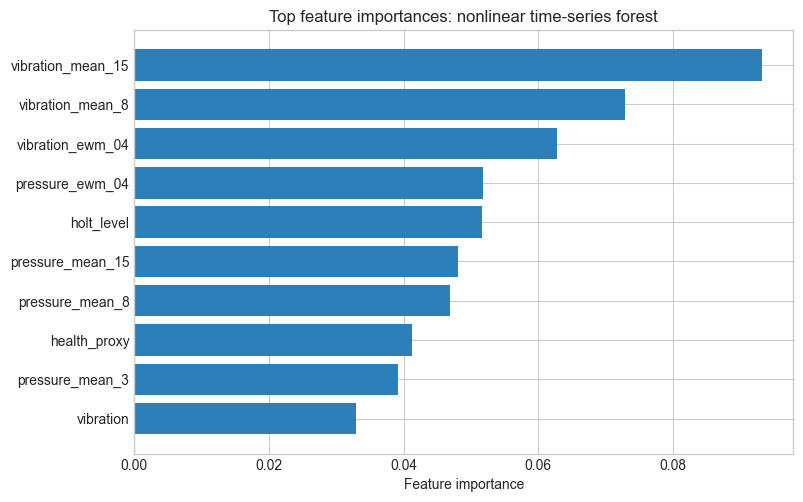

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ordered = feature_importance_df.iloc[::-1]
ax.barh(ordered["feature"], ordered["importance"], color="#2c7fb8")
ax.set_xlabel("Feature importance")
ax.set_title("Top feature importances: nonlinear time-series forest")
plt.show()

## Example risk path

A useful qualitative check is to trace predicted failure risk for one example machine over time.

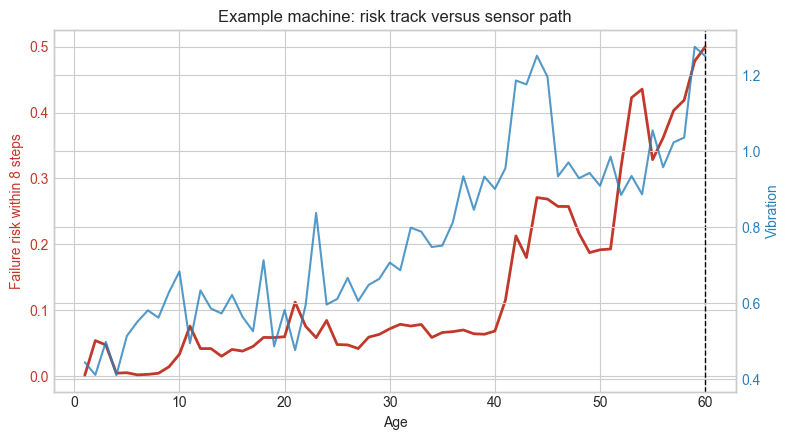

In [9]:
best_model_name = str(risk_metrics.iloc[0]["model"])
best_model = tree_model if best_model_name == "nonlinear_ts_forest" else advanced_model

machine_id = int(sorted(test_df["machine_id"].unique())[0])
sub = test_df[test_df["machine_id"] == machine_id].copy().reset_index(drop=True)
sub["predicted_risk"] = best_model.predict(sub)

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(sub["age"], sub["predicted_risk"], color="#c0392b", linewidth=2)
ax1.set_xlabel("Age")
ax1.set_ylabel("Failure risk within 8 steps", color="#c0392b")
ax1.tick_params(axis="y", labelcolor="#c0392b")
ax1.axvline(sub["failure_time"].iloc[0] + 1, color="black", linestyle="--", linewidth=1)

ax2 = ax1.twinx()
ax2.plot(sub["age"], sub["vibration"], color="#2980b9", alpha=0.8)
ax2.set_ylabel("Vibration", color="#2980b9")
ax2.tick_params(axis="y", labelcolor="#2980b9")
ax1.set_title("Example machine: risk track versus sensor path")
fig.tight_layout()
plt.show()

## Stationarity diagnostics

Because this is a time-series project, diagnostics matter. I first check whether first-differenced sensor series behave more like stationary processes using the augmented Dickey-Fuller test.

In [10]:
stationarity = stationarity_diagnostics(train_raw)
stationarity

,series,adf_stat,p_value,crit_5pct
0,vibration_first_difference,-19.078939,0.000000e+00,-2.862167
1,temperature_first_difference,-18.264524,2.327047e-30,-2.862167
2,pressure_first_difference,-22.786702,0.000000e+00,-2.862166


All three differenced sensor series reject the unit-root null strongly, which supports the use of local dynamic summaries such as rolling slopes, differences, and exponentially weighted averages.

## Calibration diagnostics

A predictive-maintenance model should output probabilities that are not only discriminative, but also reasonably calibrated.

In [11]:
calibration = pd.concat([
    calibration_table(advanced_model, test_df, "advanced_glm"),
    calibration_table(tree_model, test_df, "nonlinear_ts_forest"),
], ignore_index=True)
calibration.head()

,bin,mean_pred,observed_rate,count,model
0,"(0.00015999999999999999, 0.0116]",0.007947,0.000000,195,advanced_glm
1,"(0.0116, 0.0189]",0.015224,0.005155,194,advanced_glm
2,"(0.0189, 0.0274]",0.022979,0.015464,194,advanced_glm
3,"(0.0274, 0.0415]",0.034050,0.036082,194,advanced_glm
4,"(0.0415, 0.0725]",0.055329,0.056701,194,advanced_glm


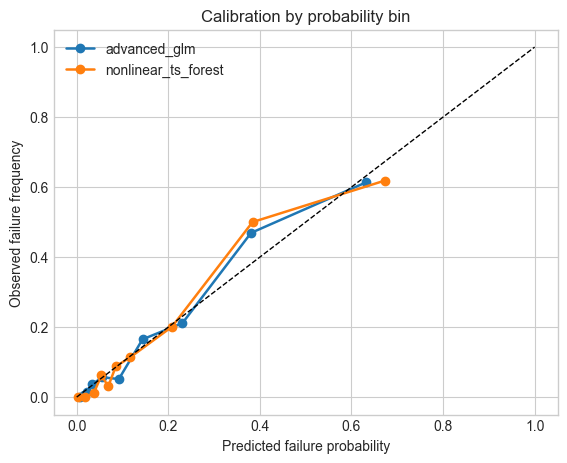

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 5.0))
for model_name, subdf in calibration.groupby("model", sort=False):
    ax.plot(subdf["mean_pred"], subdf["observed_rate"], marker="o", linewidth=1.8, label=model_name)
ax.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)
ax.set_xlabel("Predicted failure probability")
ax.set_ylabel("Observed failure frequency")
ax.set_title("Calibration by probability bin")
ax.legend(frameon=False)
plt.show()

## Residual dependence diagnostics

Residual dependence is also relevant because strong remaining autocorrelation would suggest that the model still leaves temporal structure unexplained.

In [13]:
residual_acf = pd.concat([
    residual_autocorrelation(advanced_model, test_df, "advanced_glm"),
    residual_autocorrelation(tree_model, test_df, "nonlinear_ts_forest"),
], ignore_index=True)
residual_acf

,model,lag,residual_acf
0,advanced_glm,1,0.875407
1,advanced_glm,2,0.751003
2,advanced_glm,3,0.627707
3,advanced_glm,4,0.504962
4,advanced_glm,5,0.383409
5,advanced_glm,6,0.266691
6,advanced_glm,7,0.155963
7,advanced_glm,8,0.053223
8,nonlinear_ts_forest,1,0.868084
9,nonlinear_ts_forest,2,0.743757


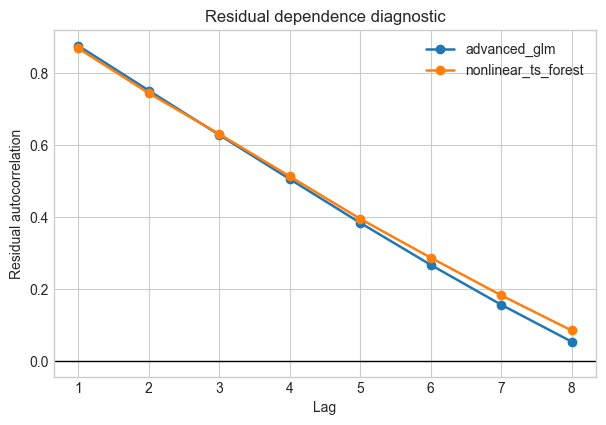

In [14]:
fig, ax = plt.subplots(figsize=(7.0, 4.5))
for model_name, subdf in residual_acf.groupby("model", sort=False):
    ax.plot(subdf["lag"], subdf["residual_acf"], marker="o", linewidth=1.8, label=model_name)
ax.axhline(0.0, color="black", linewidth=1)
ax.set_xlabel("Lag")
ax.set_ylabel("Residual autocorrelation")
ax.set_title("Residual dependence diagnostic")
ax.legend(frameon=False)
plt.show()

## Policy evaluation

To connect the forecasting layer to a practical decision problem, I compare several maintenance policies:

- reactive maintenance
- fixed-age replacement
- a tuned risk-threshold rule
- tabular Q-learning
- a compact DQN extension

For the class project, the main interpretation should still focus on the forecasting layer. The policy comparison is included to show operational consequences of better prediction.

In [15]:
threshold = tune_threshold_policy(valid_df, best_model)
q_table = train_q_learning_policy(best_model)
dqn_policy, dqn_history = train_dqn_policy(best_model)

reactive = evaluate_policy(4000, best_model, "reactive", lambda state, obs: 0)
age_based = evaluate_policy(5000, best_model, "age_threshold_75", lambda state, obs: int(obs["age"] >= 75))
risk_based = evaluate_policy(6000, best_model, f"risk_threshold_{threshold:.2f}", lambda state, obs, thr=threshold: int(obs["risk"] >= thr))
q_learning = evaluate_policy(7000, best_model, "q_learning", q_policy_from_table(q_table))
dqn_learning = evaluate_policy(8000, best_model, "dqn", dqn_policy)

policy_summary = pd.DataFrame([
    reactive,
    age_based,
    risk_based,
    q_learning,
    dqn_learning,
]).sort_values("avg_cost")

policy_summary

,policy,avg_reward,avg_cost,avg_replacements,avg_failures
2,risk_threshold_0.25,-77.642857,77.642857,2.785714,0.357143
3,q_learning,-100.428571,100.428571,4.357143,0.285714
1,age_threshold_75,-200.642857,200.642857,2.285714,2.071429
0,reactive,-203.571429,203.571429,2.142857,2.142857
4,dqn,-223.928571,223.928571,2.357143,2.357143


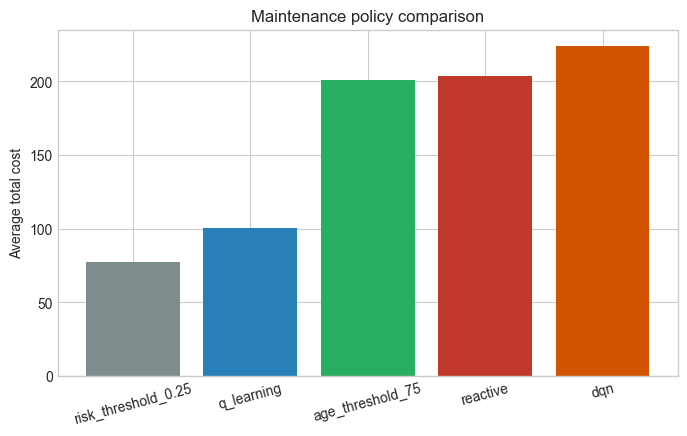

In [16]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(policy_summary["policy"], policy_summary["avg_cost"], color=["#7f8c8d", "#2980b9", "#27ae60", "#c0392b", "#d35400"])
ax.set_ylabel("Average total cost")
ax.set_title("Maintenance policy comparison")
plt.xticks(rotation=15)
plt.show()

The strongest operational result is that the tuned risk-threshold policy achieves the lowest average cost. This supports the main project claim: stronger time-series risk estimation matters more than using a more complicated controller.

## Optional DQN training history

The DQN baseline is included as an extension rather than the centerpiece of the project. I include its training history here for completeness.

In [17]:
dqn_history

,episode,reward,epsilon,mean_loss
0,1,-1224.0,1.000000,20.440345
1,2,-1242.0,0.965000,0.000270
2,3,-1224.0,0.931225,0.000139
3,4,-1314.0,0.898632,0.000189
4,5,-1134.0,0.867180,0.000326
5,6,-1080.0,0.836829,0.000313
6,7,-990.0,0.807540,0.000362
7,8,-1098.0,0.779276,0.000315
8,9,-810.0,0.752001,0.000498
9,10,-864.0,0.725681,0.000463


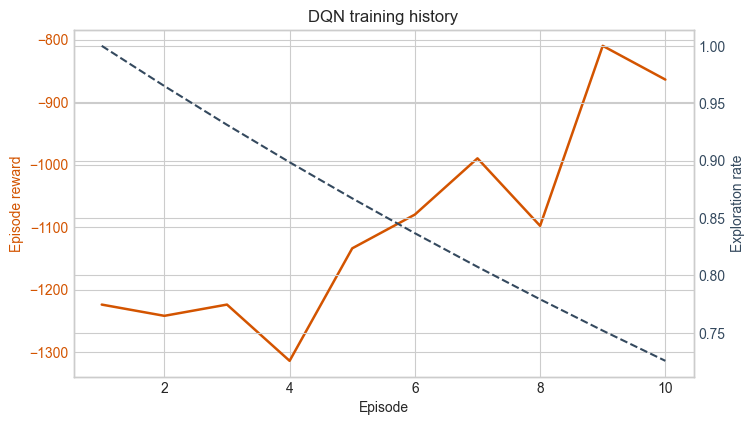

In [18]:
fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(dqn_history["episode"], dqn_history["reward"], color="#d35400", linewidth=1.8)
ax1.set_xlabel("Episode")
ax1.set_ylabel("Episode reward", color="#d35400")
ax1.tick_params(axis="y", labelcolor="#d35400")

ax2 = ax1.twinx()
ax2.plot(dqn_history["episode"], dqn_history["epsilon"], color="#34495e", linestyle="--", linewidth=1.5)
ax2.set_ylabel("Exploration rate", color="#34495e")
ax2.tick_params(axis="y", labelcolor="#34495e")
ax1.set_title("DQN training history")
plt.show()

## Save notebook results to the repository outputs folder

The next cell is optional. It writes the tables produced in this notebook into the same `outputs/` directory used by the scripted pipeline.

In [19]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

dataset_summary_df.to_csv(output_dir / "dataset_summary.csv", index=False)
risk_metrics.to_csv(output_dir / "risk_model_metrics.csv", index=False)
feature_importance_df.to_csv(output_dir / "feature_importance_top10.csv", index=False)
policy_summary.to_csv(output_dir / "policy_summary.csv", index=False)
stationarity.to_csv(output_dir / "stationarity_diagnostics.csv", index=False)
calibration.to_csv(output_dir / "calibration_summary.csv", index=False)
residual_acf.to_csv(output_dir / "residual_acf.csv", index=False)
dqn_history.to_csv(output_dir / "dqn_training_history.csv", index=False)

## Conclusion

This notebook satisfies the core code-report goals of the project:

- it contains a written narrative connecting the code to the analysis
- it includes preprocessing, feature engineering, modeling, diagnostics, and visualization code
- it uses a reproducible synthetic dataset generated inside the repository
- it provides an end-to-end workflow that someone familiar with the methods can follow without the oral presentation

The main substantive conclusion is that the largest gains come from better temporal representation of sensor behavior, which improves failure-risk prediction and leads to better maintenance decisions.